In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, f1_score, make_scorer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
from sklearn.impute import SimpleImputer
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.semi_supervised import LabelPropagation, LabelSpreading, SelfTrainingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import optuna

/Users/pritibhunia/repos/medium-voltage-cable/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
filePath = "/Users/pritibhunia/repos/medium-voltage-cable/Real Data/TD_complete_updated_20241219.csv"
data = pd.read_csv(filePath, delimiter=';')
data.dropna(inplace=True)
print(data.head())


   cable_id  meas_id cable_type_group        date      time  step_id  line_nr  \
0         2      132     Papier-Masse  2021-04-29  09:42:37     2099        1   
1         2      132     Papier-Masse  2021-04-29  09:42:37     2100        1   
2         2      132     Papier-Masse  2021-04-29  09:42:37     2101        1   
3         2      132     Papier-Masse  2021-04-29  09:42:37     2102        1   
4         2      132     Papier-Masse  2021-04-29  09:42:37     2103        2   

   voltage_step_factor    MTD    STD  ...  Skirt Type MTD@1.0   DTD  \
0                  0.5  3.950  0.050  ...  Increasing   4.583  2.65   
1                  1.0  4.583  0.037  ...  Increasing   4.583  2.65   
2                  1.5  6.600  0.082  ...  Increasing   4.583  2.65   
3                  2.0  9.750  0.050  ...  Increasing   4.583  2.65   
4                  0.5  4.333  0.047  ...  Increasing   5.117  2.55   

   Line Deviation category_mtd category_dtd category_std  \
0            2.21         

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2763 entries, 0 to 2781
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   cable_id                      2763 non-null   int64  
 1   meas_id                       2763 non-null   int64  
 2   cable_type_group              2763 non-null   object 
 3   date                          2763 non-null   object 
 4   time                          2763 non-null   object 
 5   step_id                       2763 non-null   int64  
 6   line_nr                       2763 non-null   int64  
 7   voltage_step_factor           2763 non-null   float64
 8   MTD                           2763 non-null   float64
 9   STD                           2763 non-null   float64
 10  Skirt                         2763 non-null   float64
 11  Skirt Type                    2763 non-null   object 
 12  MTD@1.0                       2763 non-null   float64
 13  DTD     

In [4]:
data

,cable_id,meas_id,cable_type_group,date,time,step_id,line_nr,voltage_step_factor,MTD,STD,...,Skirt Type,MTD@1.0,DTD,Line Deviation,category_mtd,category_dtd,category_std,category_line_deviation,additional_skirt_information,category_final
0,2,132,Papier-Masse,2021-04-29,09:42:37,2099,1,0.5,3.950,0.050,...,Increasing,4.583,2.650,2.21,1,1,1,3,"Water tree Alterung, TE Aktivitäten",3
1,2,132,Papier-Masse,2021-04-29,09:42:37,2100,1,1.0,4.583,0.037,...,Increasing,4.583,2.650,2.4,1,1,1,3,"Water tree Alterung, TE Aktivitäten",3
2,2,132,Papier-Masse,2021-04-29,09:42:37,2101,1,1.5,6.600,0.082,...,Increasing,4.583,2.650,2.13,1,1,1,3,"Water tree Alterung, TE Aktivitäten",3
3,2,132,Papier-Masse,2021-04-29,09:42:37,2102,1,2.0,9.750,0.050,...,Increasing,4.583,2.650,2.02,1,1,1,3,"Water tree Alterung, TE Aktivitäten",3
4,2,132,Papier-Masse,2021-04-29,09:42:37,2103,2,0.5,4.333,0.047,...,Increasing,5.117,2.550,2.01,1,1,1,3,"Water tree Alterung, TE Aktivitäten",3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2777,175,212,Mischkabel,2022-11-16,12:59:05,3862,3,0.8,0.021,0.029,...,Decreasing,0.164,0.148,Not given,1,1,1,Not given,Ansatzweise Feuchtigkeit,1
2778,175,212,Mischkabel,2022-11-16,12:59:05,3863,3,1.0,0.164,0.196,...,Decreasing,0.164,0.148,Not given,1,1,1,Not given,Ansatzweise Feuchtigkeit,1
2779,175,212,Mischkabel,2022-11-16,12:59:05,3864,3,1.3,0.083,0.108,...,Decreasing,0.164,0.148,2.52,1,1,1,3,Ansatzweise Feuchtigkeit,3
2780,175,212,Mischkabel,2022-11-16,12:59:05,3865,3,1.5,0.154,0.130,...,Increasing,0.164,0.148,5.31,1,1,1,4,Leichte water tree Alterung,4


In [5]:
target_column = 'category_final'

In [6]:
# find out columns of object dtypes
object_cols = data.select_dtypes(include=["object"]).columns

# get distinct values
for col in object_cols:
    print(f"Distinct values in '{col}' column:")
    print(data[col].unique())
    print("-" * 30)

Distinct values in 'cable_type_group' column:
['Papier-Masse' 'Mischkabel' 'XLPE']
------------------------------
Distinct values in 'date' column:
['2021-04-29' '2021-04-27' '2021-04-28' '2023-04-20' '2019-10-10'
 '2019-10-11' '2022-09-13' '2021-09-28' '2021-10-21' '2021-10-14'
 '2021-10-05' '2021-10-04' '2021-11-01' '2021-09-23' '2021-10-06'
 '2021-09-30' '2021-11-22' '2021-09-13' '2021-09-20' '2021-12-08'
 '2021-10-07' '2021-10-12' '2021-10-19' '2021-10-18' '2021-10-20'
 '2021-10-13' '2021-10-11' '2021-09-21' '2021-09-08' '2021-09-16'
 '2021-06-10' '2021-09-14' '2021-11-25' '2021-09-07' '2021-09-09'
 '2021-12-07' '2022-09-10' '2022-09-12' '2021-09-27' '2021-09-06'
 '2022-11-14' '2022-11-17' '2023-04-18' '2023-04-19' '2022-11-15'
 '2022-12-14' '2022-11-16' '2022-12-12' '2022-12-13' '2022-12-15'
 '2023-04-17' '2022-11-18']
------------------------------
Distinct values in 'time' column:
['09:42:37' '10:04:43' '15:23:37' '15:18:34' '13:58:51' '14:05:00'
 '11:39:48' '09:09:39' '15:58:17

In [7]:
data.isnull().sum()

cable_id                        0
meas_id                         0
cable_type_group                0
date                            0
time                            0
step_id                         0
line_nr                         0
voltage_step_factor             0
MTD                             0
STD                             0
Skirt                           0
Skirt Type                      0
MTD@1.0                         0
DTD                             0
Line Deviation                  0
category_mtd                    0
category_dtd                    0
category_std                    0
category_line_deviation         0
additional_skirt_information    0
category_final                  0
dtype: int64

In [8]:
enc = LabelEncoder()
for col in object_cols:
    data[col] = enc.fit_transform(data[col])

In [9]:
for col in object_cols:
    print(f"Distinct values in '{col}' column:")
    print(data[col].unique())
    print("-" * 30)

Distinct values in 'cable_type_group' column:
[1 0 2]
------------------------------
Distinct values in 'date' column:
[ 4  2  3 51  0  1 38 17 30 26 20 19 31 15 21 18 32 10 13 35 22 24 28 27
 29 25 23 14  8 12  5 11 33  7  9 34 36 37 16  6 39 42 49 50 40 46 41 44
 45 47 48 43]
------------------------------
Distinct values in 'time' column:
[ 32  44 139 138 125 127  79  19 144 114  77 117  29 137  73 128  94  57
 143  17  58 101 136  25  90  54 145 135  13  26 104  35  24  65  27  87
 113  81  43  22  49  86 119  16  23 121  71  40  33  89  98  46  72 118
  48 103 115  67  75  70  30  93 120 142  61   4 110  18 126  91  97  38
 111 140  62  28  63  76  20  59 106  60  92 124  15 108  51 102  56  21
   9   3  52   0  10  11  50   6  36 123   1  47  39   8  37 131   7  42
  85 134 112  96  82 107  45  64 129  69 100  12  83 105 122  78  84 130
  99 133 116  31 132  55  88  66  68  74 141  14  34  80  53   5  41   2
  95 109]
------------------------------
Distinct values in 'Skirt Type'

                              cable_id   meas_id  cable_type_group      date  \
cable_id                      1.000000  0.717868         -0.244753  0.749244   
meas_id                       0.717868  1.000000         -0.396163  0.609278   
cable_type_group             -0.244753 -0.396163          1.000000 -0.374867   
date                          0.749244  0.609278         -0.374867  1.000000   
time                         -0.074072  0.039957         -0.129317 -0.075692   
step_id                       0.731206  0.964314         -0.443948  0.613406   
line_nr                       0.001822  0.004238         -0.004381  0.009506   
voltage_step_factor          -0.036028  0.004779         -0.007876 -0.031495   
MTD                           0.033615  0.028320          0.016688  0.024852   
STD                           0.018729  0.019770          0.012043  0.014563   
Skirt                        -0.018053 -0.019190         -0.012000 -0.013974   
Skirt Type                   -0.045625 -

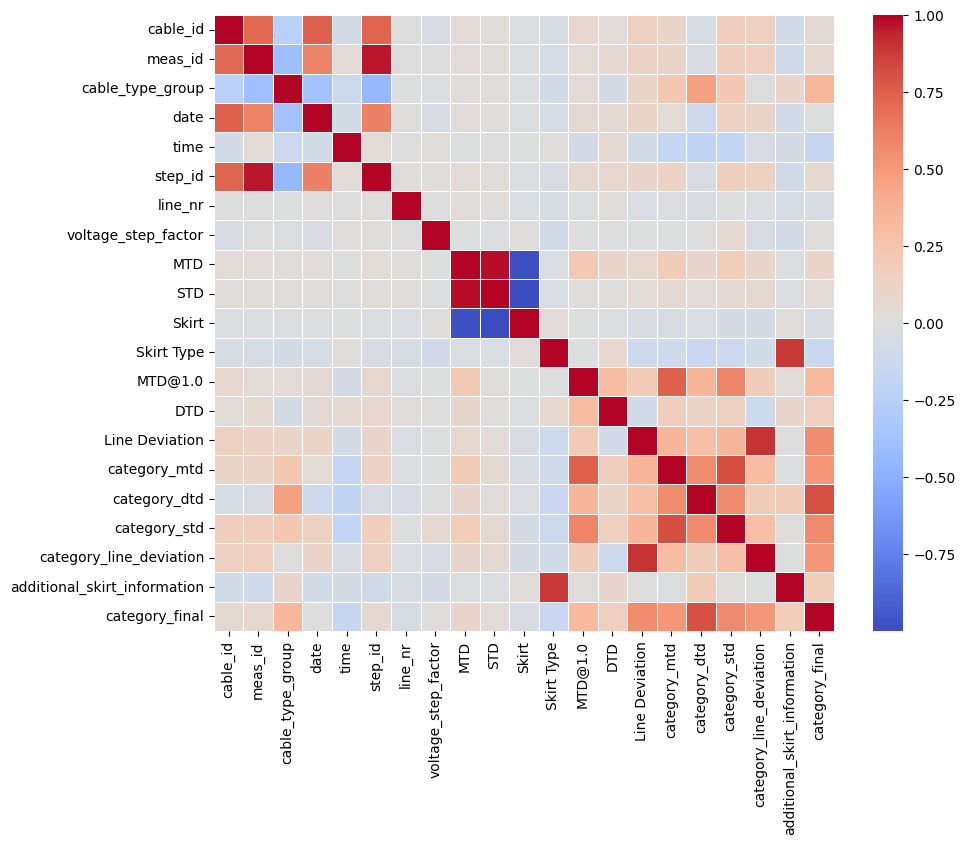

In [10]:
correlation_matrix = data.corr()
print(correlation_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.show()

                              cable_type_group   line_nr  voltage_step_factor  \
cable_type_group                      1.000000 -0.004381            -0.007876   
line_nr                              -0.004381  1.000000             0.000217   
voltage_step_factor                  -0.007876  0.000217             1.000000   
MTD                                   0.016688  0.021869            -0.000502   
STD                                   0.012043  0.023389            -0.012425   
Skirt                                -0.012000 -0.023515             0.012664   
Skirt Type                           -0.075638 -0.043344            -0.087854   
MTD@1.0                               0.036121 -0.009925            -0.006313   
DTD                                  -0.058648  0.019319             0.001173   
Line Deviation                        0.108320 -0.029287            -0.000909   
additional_skirt_information          0.099717 -0.046615            -0.068590   
category_final              

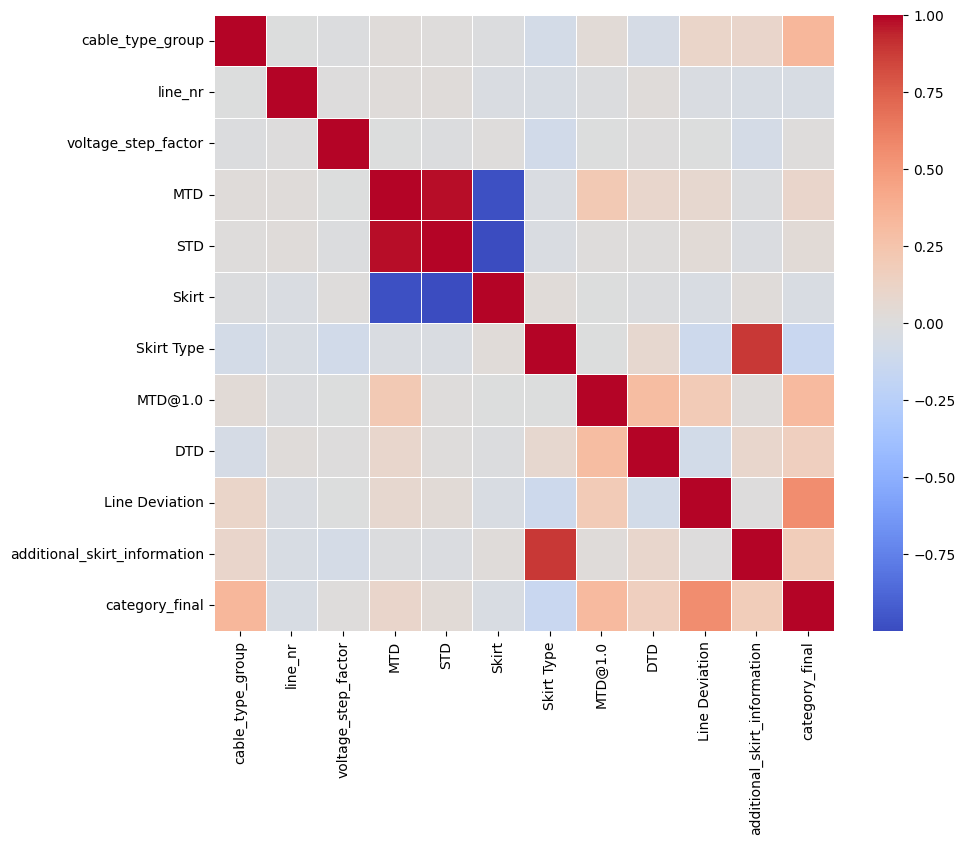

In [11]:
# drop columns with no relevance except meas_id. It is a unique identifier for each row
data_for_analysis = data.drop(['cable_id', 'date', 'time', 'step_id', 'category_mtd', 'category_dtd', 'category_std', 'category_line_deviation', 'meas_id'], axis=1)
correlation_matrix = data_for_analysis.corr()
print(correlation_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.show()

In [12]:
data_for_analysis

,cable_type_group,line_nr,voltage_step_factor,MTD,STD,Skirt,Skirt Type,MTD@1.0,DTD,Line Deviation,additional_skirt_information,category_final
0,1,1,0.5,3.950,0.050,0.02571,2,4.583,2.650,129,7,3
1,1,1,1.0,4.583,0.037,0.01429,2,4.583,2.650,146,7,3
2,1,1,1.5,6.600,0.082,0.02286,2,4.583,2.650,121,7,3
3,1,1,2.0,9.750,0.050,0.00857,2,4.583,2.650,111,7,3
4,1,2,0.5,4.333,0.047,0.02286,2,5.117,2.550,110,7,3
...,...,...,...,...,...,...,...,...,...,...,...,...
2777,0,3,0.8,0.021,0.029,-0.00157,0,0.164,0.148,309,0,1
2778,0,3,1.0,0.164,0.196,-0.04118,0,0.164,0.148,309,0,1
2779,0,3,1.3,0.083,0.108,-0.00808,0,0.164,0.148,155,0,3
2780,0,3,1.5,0.154,0.130,0.04264,2,0.164,0.148,266,4,4


In [13]:
# Drop rows where 'MTD' > 4000 and 'STD' > 5000 to remove the extreme condition
data_for_analysis = data_for_analysis[~((data_for_analysis['MTD'] > 4000) & (data_for_analysis['STD'] > 5000))]

In [14]:
# Get input/output dataframes
y = data_for_analysis[target_column]
x = data_for_analysis.drop([target_column],axis=1)

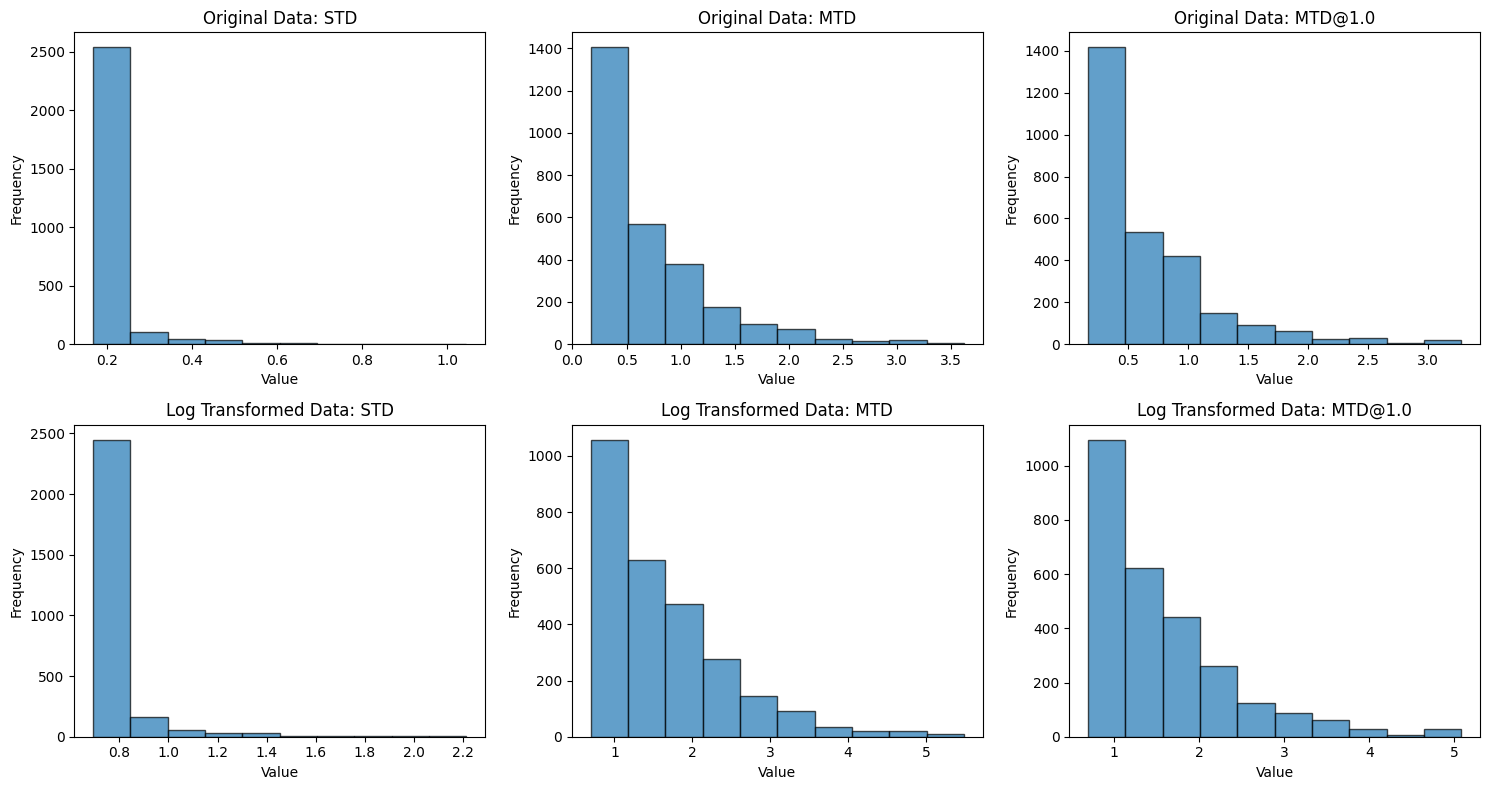

In [15]:
# Define numerical features
numerical_features = ['STD', 'MTD', 'MTD@1.0']

# Define the safe log transform function
def safe_log_transform(series):
    min_value = series.min()
    return np.log1p(series - min_value + 1) if min_value <= 0 else np.log1p(series)

# Apply log transformation with safe_log_transform
data_for_analysis.loc[:, numerical_features] = data_for_analysis[numerical_features].apply(safe_log_transform)

# Plot original vs. transformed data
fig, axes = plt.subplots(2, len(numerical_features), figsize=(15, 8))
titles = ["Original Data", "Log Transformed Data"]

for i, col in enumerate(numerical_features):
    for j, (data, title) in enumerate(zip(
        [data_for_analysis[col] - np.log1p(data_for_analysis[col]), data_for_analysis[col]], titles
    )):
        axes[j, i].hist(data, bins=10, edgecolor='k', alpha=0.7)
        axes[j, i].set_title(f"{title}: {col}")
        axes[j, i].set_xlabel("Value")
        axes[j, i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [16]:
# Standard deviation before scaling
x.std()

cable_type_group                 0.808883
line_nr                          0.816547
voltage_step_factor              0.506494
MTD                             16.791678
STD                              0.511824
Skirt                            0.180870
Skirt Type                       0.954761
MTD@1.0                         15.674216
DTD                              5.560254
Line Deviation                  72.858060
additional_skirt_information     2.404509
dtype: float64

In [17]:
# apply scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(x)
x_standardized = pd.DataFrame(scaled_features, columns=x.columns)

In [18]:
# standard deviation after scaling
x_standardized.std()

cable_type_group                1.000181
line_nr                         1.000181
voltage_step_factor             1.000181
MTD                             1.000181
STD                             1.000181
Skirt                           1.000181
Skirt Type                      1.000181
MTD@1.0                         1.000181
DTD                             1.000181
Line Deviation                  1.000181
additional_skirt_information    1.000181
dtype: float64

In [19]:
x_standardized.columns

Index(['cable_type_group', 'line_nr', 'voltage_step_factor', 'MTD', 'STD',
       'Skirt', 'Skirt Type', 'MTD@1.0', 'DTD', 'Line Deviation',
       'additional_skirt_information'],
      dtype='object')

#### Semi-Supervised Learning


# Convert target to semi-supervised format (-1 for unlabeled data)
def create_semi_supervised_labels(y, label_percentage):
    np.random.seed(30)
    labeled_indices = np.random.choice(len(y), size=int(len(y) * label_percentage), replace=False)
    y_semi = np.full_like(y, fill_value=-1, dtype=int)
    y_semi[labeled_indices] = y[labeled_indices]
    return y_semi

In [20]:
def create_semi_supervised_labels(y, label_percentage):
    np.random.seed(42)
    labeled_indices = np.random.choice(len(y), size=int(len(y) * label_percentage), replace=False)
    y_semi = np.full_like(y, fill_value=-1, dtype=int)
    y_semi[labeled_indices] = y[labeled_indices]
    return y_semi

### Let's do a grid search for both models with weighted F1-score

##### Using Grid Search

In [21]:
def run_grid_search(X, y, model_type):
    model = LabelPropagation() if model_type == 'LabelPropagation' else LabelSpreading()

    param_grid = {
        'kernel': ['rbf', 'knn'],
        'gamma': [10, 20, 50, 100]
    }

    if model_type == 'LabelSpreading':  # Only LabelSpreading supports `alpha`
        param_grid['alpha'] = [0.1, 0.3, 0.5, 0.8]

    # Let's define scoring metrics for grid search
    scoring = {'accuracy': 'accuracy', 'f1_weighted': make_scorer(f1_score, average='weighted', zero_division=0)}

    grid = GridSearchCV(model, param_grid, scoring=scoring, refit='accuracy', cv=3, n_jobs=-1)

    # Filter out unlabeled data points
    labeled_indices = y != -1
    X_labeled, y_labeled = X[labeled_indices], y[labeled_indices]

    grid.fit(X_labeled, y_labeled)

    # Now save the best estimator and parameters
    best_model = grid.best_estimator_
    best_params = grid.best_params_
    best_accuracy = grid.best_score_

    return best_params, best_accuracy, best_model

##### Using Optuna

In [22]:
def run_optuna_optimization(X, y, model_type, n_trials=20):
    # Filter labeled data
    labeled_indices = y != -1
    X_labeled, y_labeled = X[labeled_indices], y[labeled_indices]

    def objective(trial):
        if model_type in ['LabelPropagation', 'LabelSpreading']:
            kernel = trial.suggest_categorical('kernel', ['rbf', 'knn'])
            gamma = trial.suggest_categorical('gamma', [10, 20, 50, 100])
            if model_type == 'LabelPropagation':
                model = LabelPropagation(kernel=kernel, gamma=gamma)
            else:
                alpha = trial.suggest_categorical('alpha', [0.1, 0.3, 0.5, 0.8])
                model = LabelSpreading(kernel=kernel, gamma=gamma, alpha=alpha)
        else:  # Self-Training: using default SVC as base estimator
            base_estimator = SVC(probability=True, gamma='scale')
            model = SelfTrainingClassifier(base_estimator)

        # Evaluate using 3-fold cross-validation on the labeled data
        scores = cross_val_score(model, X_labeled, y_labeled, cv=3, scoring='accuracy', n_jobs=-1)
        return scores.mean()

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)
    best_params = study.best_trial.params
    best_score = study.best_value

    # Build the best model using the best parameters.
    if model_type in ['LabelPropagation', 'LabelSpreading']:
        if model_type == 'LabelPropagation':
            best_model = LabelPropagation(**best_params)
        else:
            best_model = LabelSpreading(**best_params)
    else:
        best_model = SelfTrainingClassifier(SVC(probability=True, gamma='scale'))

    # Train the best model on the full labeled data.
    best_model.fit(X_labeled, y_labeled)
    return best_params, best_score, best_model

### Progressive Validation 

labeled_percentages = [0.1, 0.2, 0.4, 0.6, 0.8]
results = []

for perc in labeled_percentages:
    y_semi = create_semi_supervised_labels(y.to_numpy(), perc)

    for model_type in ['LabelPropagation', 'LabelSpreading']:
        best_params, best_accuracy, best_model = run_grid_search(x_standardized.to_numpy(), y_semi, model_type)

        # Predict on the entire dataset (both labeled and unlabeled data)
        y_pred = best_model.predict(x_standardized.to_numpy())  # Predict all data points

        # Separate labeled and unlabeled data points
        labeled_indices = y_semi != -1
        y_true = y.to_numpy()  # True values (including labeled and unlabeled)
        
        # Calculate the weighted F1-score on the labeled data only (to compare against true labels)
        weighted_f1 = f1_score(y_true[labeled_indices], y_pred[labeled_indices], average='weighted', zero_division=0)

        results.append({
            'Model': model_type, 
            'Labeled %': perc, 
            'Best Params': best_params, 
            'Best Accuracy': best_accuracy,
            'Weighted F1 Score': weighted_f1
        })

# Convert results to DataFrame to display
results_df = pd.DataFrame(results)
print("Labeled Data Requirement Results:\n", results_df)


In [23]:
labeled_percentages = [0.1, 0.2, 0.4, 0.6, 0.8]
results = []

for perc in labeled_percentages:
    y_semi = create_semi_supervised_labels(y.to_numpy(), perc)
    
    for model_type in ['LabelPropagation', 'LabelSpreading', 'Self-Training']:
        best_params, best_accuracy, best_model = run_optuna_optimization(x_standardized.to_numpy(), y_semi, model_type, n_trials=20)
        
        # Predict on the entire dataset (both labeled and unlabeled data)
        y_pred = best_model.predict(x_standardized.to_numpy())
        
        # Only evaluate metrics on the originally labeled data
        labeled_indices = y_semi != -1
        y_true = y.to_numpy()
        weighted_f1 = f1_score(y_true[labeled_indices], y_pred[labeled_indices], average='weighted', zero_division=0)
        
        results.append({
            'Model': model_type,
            'Labeled %': perc,
            'Best Params': best_params,
            'Best Accuracy': best_accuracy,
            'Weighted F1 Score': weighted_f1
        })

# Convert results to DataFrame and display
results_df = pd.DataFrame(results)
print("Labeled Data Requirement Results:\n", results_df)

[I 2025-02-17 14:54:37,145] A new study created in memory with name: no-name-6dc9d8ac-fac2-409b-8068-c1084a3dcbd2
[I 2025-02-17 14:54:39,332] Trial 0 finished with value: 0.7681159420289857 and parameters: {'kernel': 'knn', 'gamma': 100}. Best is trial 0 with value: 0.7681159420289857.
[I 2025-02-17 14:54:39,849] Trial 1 finished with value: 0.7681159420289857 and parameters: {'kernel': 'knn', 'gamma': 100}. Best is trial 0 with value: 0.7681159420289857.
[I 2025-02-17 14:54:39,863] Trial 2 finished with value: 0.7681159420289857 and parameters: {'kernel': 'knn', 'gamma': 100}. Best is trial 0 with value: 0.7681159420289857.
/Users/pritibhunia/repos/medium-voltage-cable/.venv/lib/python3.12/site-packages/sklearn/semi_supervised/_label_propagation.py:230: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
/Users/pritibhunia/repos/medium-voltage-cable/.venv/lib/python3.12/site-packages/sklearn/semi_supervised/_label_propagation.py:230: RuntimeWarning: inval

Labeled Data Requirement Results:
                Model  Labeled %  \
0   LabelPropagation        0.1   
1     LabelSpreading        0.1   
2      Self-Training        0.1   
3   LabelPropagation        0.2   
4     LabelSpreading        0.2   
5      Self-Training        0.2   
6   LabelPropagation        0.4   
7     LabelSpreading        0.4   
8      Self-Training        0.4   
9   LabelPropagation        0.6   
10    LabelSpreading        0.6   
11     Self-Training        0.6   
12  LabelPropagation        0.8   
13    LabelSpreading        0.8   
14     Self-Training        0.8   

                                      Best Params  Best Accuracy  \
0                 {'kernel': 'knn', 'gamma': 100}       0.768116   
1    {'kernel': 'knn', 'gamma': 50, 'alpha': 0.8}       0.706522   
2                                              {}       0.855072   
3                 {'kernel': 'knn', 'gamma': 100}       0.764493   
4    {'kernel': 'knn', 'gamma': 50, 'alpha': 0.8}       0.726449

#### Let's plot now

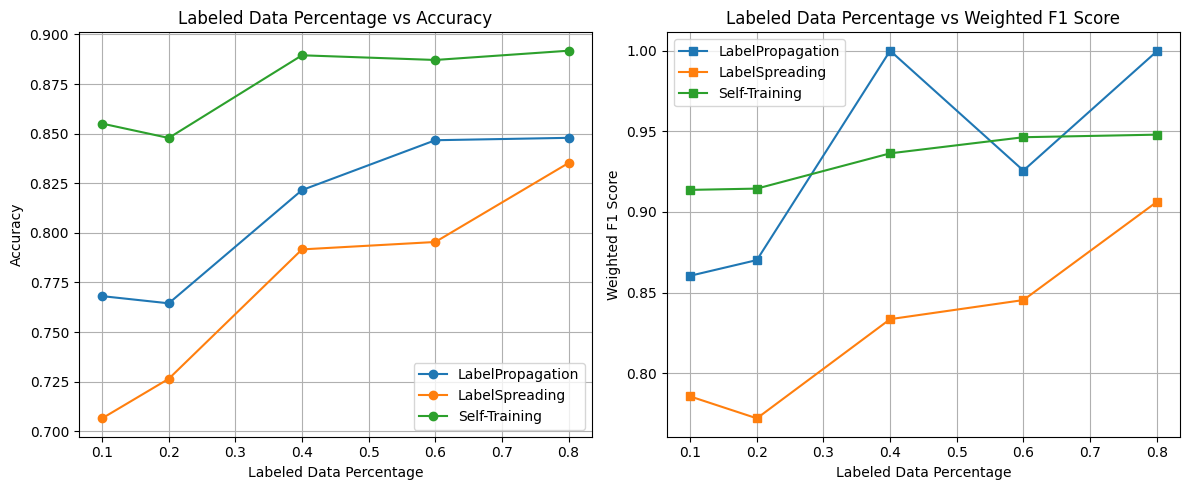

In [24]:
plt.figure(figsize=(12, 5))

# Subplot 1: Accuracy vs Labeled Percentage
plt.subplot(1, 2, 1)
for model_type in ['LabelPropagation', 'LabelSpreading', 'Self-Training']:
    subset = results_df[results_df['Model'] == model_type]
    plt.plot(subset['Labeled %'], subset['Best Accuracy'], marker='o', label=f"{model_type}")

plt.title('Labeled Data Percentage vs Accuracy')
plt.xlabel('Labeled Data Percentage')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Subplot 2: Weighted F1 Score vs Labeled Percentage
plt.subplot(1, 2, 2)
for model_type in ['LabelPropagation', 'LabelSpreading', 'Self-Training']:
    subset = results_df[results_df['Model'] == model_type]
    plt.plot(subset['Labeled %'], subset['Weighted F1 Score'], marker='s', label=f"{model_type}")

plt.title('Labeled Data Percentage vs Weighted F1 Score')
plt.xlabel('Labeled Data Percentage')
plt.ylabel('Weighted F1 Score')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

### Missing Data

In [25]:
def add_missing_data(X, missing_percentage, column):
    X_missing = X.copy()
    np.random.seed(42)
    total_values = X_missing[column].shape[0]
    n_missing = int(total_values * missing_percentage)
    missing_indices = np.random.choice(X_missing.index, n_missing, replace=False)
    X_missing.loc[missing_indices, column] = np.nan
    return X_missing

In [26]:
def create_semi_supervised_labels(y, label_percentage):
    np.random.seed(42)
    y_semi = y.copy()
    total_labels = len(y_semi)
    n_labeled = int(total_labels * label_percentage)
    labeled_indices = np.random.choice(np.arange(total_labels), n_labeled, replace=False)
    y_semi[:] = -1  # Mark all as unlabeled
    y_semi[labeled_indices] = y[labeled_indices]  # Retain true labels for a subset
    return y_semi

#### Run Experiment for Each Column & Missing Percentage

In [27]:
missing_columns = ['additional_skirt_information', 'Skirt Type']
missing_percentages = [0.1, 0.2, 0.4]
missing_results = []

for column in missing_columns:
    for perc in missing_percentages:
        # Introduce missing data into one specific column.
        X_missing = add_missing_data(x_standardized, perc, column)
        # Impute missing values.
        imputer = SimpleImputer(strategy='mean')
        X_imputed = imputer.fit_transform(X_missing)
        
        # Create semi-supervised labels (e.g., 40% labeled data).
        y_semi = create_semi_supervised_labels(y.to_numpy(), 0.4)
        
        # Loop over the two models.
        for model_type in ['LabelPropagation', 'LabelSpreading']:
            best_params, best_score, best_model = run_optuna_optimization(X_imputed, y_semi, model_type, n_trials=20)
            
            # Predict on the entire dataset.
            y_pred = best_model.predict(X_imputed)
            # Evaluate on the originally unlabeled samples.
            unlabeled_indices = y_semi == -1
            y_true = y.to_numpy()[unlabeled_indices]
            y_pred_unlabeled = y_pred[unlabeled_indices]
            if len(y_true) > 0:
                weighted_f1 = f1_score(y_true, y_pred_unlabeled, average='weighted', zero_division=0)
            else:
                weighted_f1 = np.nan
            
            missing_results.append({
                'Model': model_type,
                'Missing %': perc,
                'Missing Column': column,
                'Best Params': best_params,
                'Best Accuracy': best_score,
                'Weighted F1 Score': weighted_f1
            })

# Convert results to DataFrame.
missing_results_df = pd.DataFrame(missing_results)
print("Fixed Missing Data Results:\n", missing_results_df)

[I 2025-02-17 14:54:55,897] A new study created in memory with name: no-name-fa6f4a86-8e78-4b84-ba0b-0a56d91745b1
/Users/pritibhunia/repos/medium-voltage-cable/.venv/lib/python3.12/site-packages/sklearn/semi_supervised/_label_propagation.py:230: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
/Users/pritibhunia/repos/medium-voltage-cable/.venv/lib/python3.12/site-packages/sklearn/semi_supervised/_label_propagation.py:230: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
/Users/pritibhunia/repos/medium-voltage-cable/.venv/lib/python3.12/site-packages/sklearn/semi_supervised/_label_propagation.py:230: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer
[I 2025-02-17 14:54:55,978] Trial 0 finished with value: 0.7653985507246377 and parameters: {'kernel': 'rbf', 'gamma': 100}. Best is trial 0 with value: 0.7653985507246377.
/Users/pritibhunia/repos/medium-voltage-cable/.venv/lib/python3.12/site

Fixed Missing Data Results:
                Model  Missing %                Missing Column  \
0   LabelPropagation        0.1  additional_skirt_information   
1     LabelSpreading        0.1  additional_skirt_information   
2   LabelPropagation        0.2  additional_skirt_information   
3     LabelSpreading        0.2  additional_skirt_information   
4   LabelPropagation        0.4  additional_skirt_information   
5     LabelSpreading        0.4  additional_skirt_information   
6   LabelPropagation        0.1                    Skirt Type   
7     LabelSpreading        0.1                    Skirt Type   
8   LabelPropagation        0.2                    Skirt Type   
9     LabelSpreading        0.2                    Skirt Type   
10  LabelPropagation        0.4                    Skirt Type   
11    LabelSpreading        0.4                    Skirt Type   

                                      Best Params  Best Accuracy  \
0                 {'kernel': 'rbf', 'gamma': 100}       0

#### Plotting

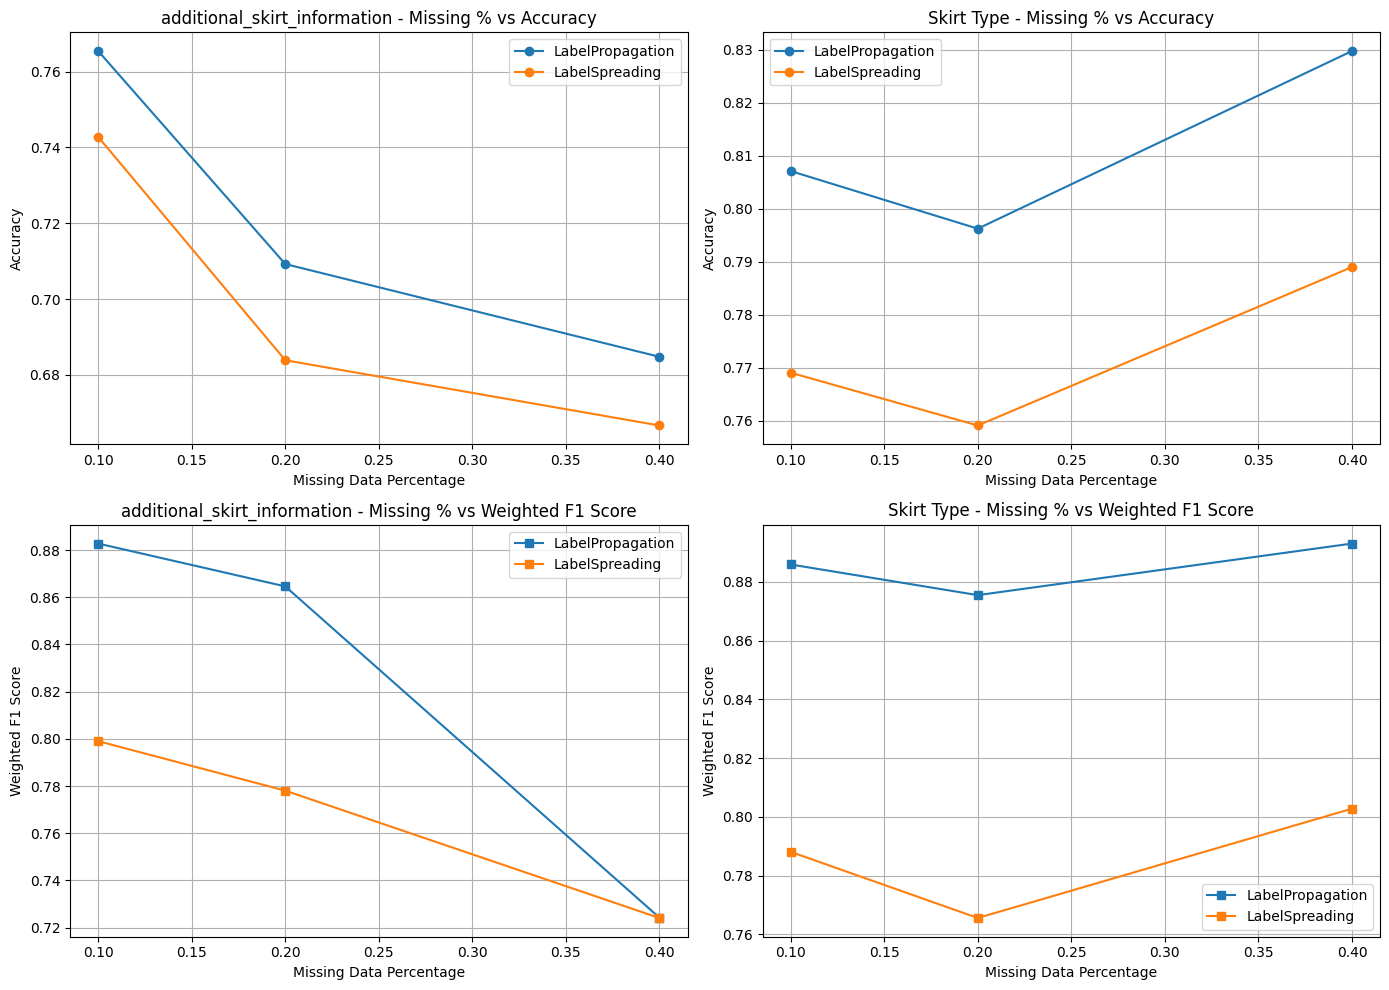

In [28]:
plt.figure(figsize=(14, 10))

for idx, column in enumerate(missing_columns, start=1):
    # Plot Accuracy vs Missing Percentage for this column.
    plt.subplot(2, len(missing_columns), idx)
    for model_type in ['LabelPropagation', 'LabelSpreading']:
        subset = missing_results_df[(missing_results_df['Model'] == model_type) & 
                                    (missing_results_df['Missing Column'] == column)]
        plt.plot(subset['Missing %'], subset['Best Accuracy'], marker='o', label=f"{model_type}")
    plt.title(f'{column} - Missing % vs Accuracy')
    plt.xlabel('Missing Data Percentage')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()
    
    # Plot Weighted F1 Score vs Missing Percentage for this column.
    plt.subplot(2, len(missing_columns), len(missing_columns) + idx)
    for model_type in ['LabelPropagation', 'LabelSpreading']:
        subset = missing_results_df[(missing_results_df['Model'] == model_type) & 
                                    (missing_results_df['Missing Column'] == column)]
        plt.plot(subset['Missing %'], subset['Weighted F1 Score'], marker='s', label=f"{model_type}")
    plt.title(f'{column} - Missing % vs Weighted F1 Score')
    plt.xlabel('Missing Data Percentage')
    plt.ylabel('Weighted F1 Score')
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.show()